In [2]:
import sys 
sys.path.append('C:/Users/DATA/Documents/datos/01_script/inicio/funciones')
from funciones import *
from funciones_spark import *
from variables_inicio import *
from utils_sql import *

spark = SparkSession.builder \
    .appName("SparkExample") \
    .master("local[*]") \
    .config('spark.driver.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.extraClassPath', 'C:/spark/jars/mssql-jdbc-13.2.1.jre11.jar') \
    .config('spark.executor.memory', '8g') \
    .config('spark.driver.memory', '8g') \
    .getOrCreate()

In [22]:
query = """
  select fecha as fecha_llamada,dni as dni_cliente,telefono,  1 as desembolso from VALENTINA.dbo.alfin_ventas
where estado in(4,13,0)
  and fecha<'2026-05-01'
    """
df_desembolso = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("fecha_llamada").desc())
df_desembolso = df_desembolso.withColumn("ref_01", row_number().over(window_spec))
df_desembolso = df_desembolso.filter(col("ref_01") == 1).drop('ref_01')

df_desembolso = df_desembolso.withColumn(
    "dif_meses",
    F.floor(
        F.months_between(
            F.to_date(F.lit('2026-05-01')),
            F.col("fecha_llamada")
        )
    )
)
df_desembolso = df_desembolso.withColumn(
    "dni_cliente",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni_cliente")),
        F.lit(8)
    )

)
query = """
  SELECT distinct dni_cliente FROM cronox.dbo.borrar_alfin_01
    """
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)


df_list = df_list.withColumn(
    "dni_cliente",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni_cliente")),
        F.lit(8)
    )

)
df_desembolso=df_desembolso.join(df_list,['dni_cliente'],'inner')
df_desembolso.count()

849

In [23]:
df_desembolso.groupBy('dif_meses') \
    .count() \
    .orderBy('dif_meses') \
    .show(30)


+---------+-----+
|dif_meses|count|
+---------+-----+
|        0|  138|
|        1|   56|
|        2|   56|
|        3|  115|
|        4|  107|
|        5|  140|
|        6|   51|
|        7|   65|
|        8|   67|
|        9|   54|
+---------+-----+



In [27]:
df_desembolso=df_desembolso.withColumn('marca',when(F.col('dif_meses').isin(0,1),'INVENTARIO TARGET 0')
                                                .when(F.col('dif_meses').isin(2,3,4),'INVENTARIO TARGET 1')
                                                .otherwise(F.lit('INVENTARIO TARGET 2'))
)

In [ ]:
query = """
    select 
    a.dni_cliente, 
    a.Fecha as fecha_llamada,
    a.hora,
    a.celular,
    a.Tipificacion as peso,
    a.Campaña,
    b.nivel_1,
    b.nivel_2 
    FROM VALENTINA.dbo.alfin_gestion a
    LEFT JOIN VALENTINA.dbo.alfin_tipificaciones B 
    ON A.Tipificacion = B.id_banco
    where a.fecha<'2026-06-01'
    """
df_gestion = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("peso").asc(),F.col("fecha_llamada").desc(),F.col("hora").desc())
df_gestion = df_gestion.withColumn("ref_01", row_number().over(window_spec))
df_gestion = df_gestion.filter(col("ref_01") == 1).drop('ref_01')

In [33]:
nivel_2=[
'CLIENTE ACEPTO OFERTA',
 'NO SE CONCRETO LLAMADA',
 'CLIENTE INTERESADO (VOLVER A LLAMAR)',
 'CLIENTE VIVE / LABORA / DE VIAJE EN EXTRANJERO',
 'CLIENTE YA TIENE PRODUCTO',
 'VERIFICACION',
 'TELEFONO APAGADO',
 'SE DEJO ENCARGO EN OFICINA (VOLVER A LLAMAR)',
 'CLIENTE VIVE / LABORA / DE VIAJE EN PROVINCIA',
 'SE DEJO ENCARGO EN DOMICILIO (VOLVER A LLAMAR)',
 'TELEFONO OCUPADO (NO CONTESTAN)',
 'CLIENTE NO DESEA'
 ]

In [34]:
df_gestion=df_gestion.filter(F.col('nivel_2').isin(nivel_2))
df_gestion=df_gestion.filter(F.col('nivel_1').isin('CONTACTO EFECTIVO CON TITULAR'))
df_gestion = df_gestion.withColumn(
    "dni_cliente",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni_cliente")),
        F.lit(8)
    )

)

In [35]:
df_gestion=df_gestion.join(df_list,['dni_cliente'],'inner')
df_gestion=df_gestion.join(df_desembolso,['dni_cliente'],'leftanti')

In [36]:
df_gestion = df_gestion.withColumn(
    "dif_meses",
    F.floor(
        F.months_between(
            F.to_date(F.lit('2026-05-01')),
            F.col("fecha_llamada")
        )
    )
)

In [37]:
df_gestion.groupBy('dif_meses') \
    .count() \
    .orderBy('dif_meses') \
    .show(30)


+---------+-----+
|dif_meses|count|
+---------+-----+
|        0| 3469|
|        1| 1093|
|        2|  875|
|        3| 1732|
|        4| 1611|
|        5| 1669|
|        6|  763|
|        7|  821|
|        8|  712|
|        9|  561|
|       10|    1|
+---------+-----+



In [50]:
df_gestion=df_gestion.withColumn('marca',when(F.col('dif_meses').isin(0,1),'CET TARGET 0')
                                                .when(F.col('dif_meses').isin(2,3,4),'CET TARGET 1')
                                                .otherwise(F.lit('CET TARGET 2'))
)

In [39]:
print(df_gestion.columns)
print(df_desembolso.columns)

['dni_cliente', 'fecha_llamada', 'hora', 'celular', 'peso', 'Campaña', 'nivel_1', 'nivel_2', 'dif_meses', 'marca']
['dni_cliente', 'fecha_llamada', 'telefono', 'desembolso', 'dif_meses', 'marca']


In [51]:
df_gestion_pd = df_gestion.select('dni_cliente', 'celular', 'marca').toPandas()
# df_desembolso_pd = df_desembolso.select('dni_cliente', 'telefono', 'marca').toPandas()

In [52]:
reemplazo = {
    'dni_cliente': 'col_01',
    'celular': 'col_02',
    'marca': 'col_03',
}
df_gestion_pd = df_gestion_pd.rename(columns=reemplazo)
# reemplazo = {
#     'dni_cliente': 'col_01',
#     'telefono': 'col_02',
#     'marca': 'col_03',
# }
# df_desembolso_pd = df_desembolso_pd.rename(columns=reemplazo)

In [42]:
from sqlalchemy import create_engine


engine_mysql = create_engine(
    f"mysql+pymysql://{user_valentina}:{pwd_valentina}@{server_valentina}:{port_mysql}/{db_valentina}"
)
from sqlalchemy import text

query = """
DELETE FROM crm_target.tb_temporal
"""

with engine_mysql.begin() as conn:
    result = conn.execute(text(query))
    print("Filas eliminadas:", result.rowcount)

Filas eliminadas: 0


In [60]:
query = """
DELETE FROM crm_target.tb_temporal
"""

with engine_mysql.begin() as conn:
    result = conn.execute(text(query))
    print("Filas eliminadas:", result.rowcount)
    

Filas eliminadas: 13307


In [58]:
df_gestion_pd[['col_01','col_02','col_03']].to_sql(
    name="tb_temporal",
    con=engine_mysql,
    if_exists="append",
    index=False,
    chunksize=1000
)
df_gestion_pd.head()

,col_01,col_02,col_03
0,00004873,961659543,CET TARGET 1
1,00008377,945931324,CET TARGET 0
2,00008850,916997012,CET TARGET 1
3,00009483,987973309,CET TARGET 1
4,00011581,949637983,CET TARGET 1


In [44]:
from sqlalchemy import text

query = """
UPDATE crm_target.alfin_clientes a
INNER JOIN crm_target.tb_temporal b
    ON a.NUMERO_DOCUMENTO = b.col_01 
SET 
    a.PROVEEDOR = b.col_03,
    a.cl_telf7 = b.col_02
WHERE 
    a.cl_base = 'mayo 2026'
"""

with engine_mysql.begin() as conn:
    result = conn.execute(text(query))
    print("Filas afectadas:", result.rowcount)

Filas afectadas: 849


In [47]:
df_gestion_pd[['col_01','col_02','col_03']].to_sql(
    name="tb_temporal",
    con=engine_mysql,
    if_exists="append",
    index=False,
    chunksize=1000
)
df_gestion_pd.head()

,col_01,col_02,col_03
0,00004873,961659543,INVENTARIO TARGET 1
1,00008377,945931324,INVENTARIO TARGET 0
2,00008850,916997012,INVENTARIO TARGET 1
3,00009483,987973309,INVENTARIO TARGET 1
4,00011581,949637983,INVENTARIO TARGET 1


In [59]:
from sqlalchemy import text

query = """
UPDATE crm_target.alfin_clientes a
INNER JOIN crm_target.tb_temporal b
    ON a.NUMERO_DOCUMENTO = b.col_01 
SET 
    a.PROVEEDOR = b.col_03,
    a.cl_telf7 = b.col_02
WHERE 
    a.cl_base = 'mayo 2026'
"""

with engine_mysql.begin() as conn:
    result = conn.execute(text(query))
    print("Filas afectadas:", result.rowcount)

Filas afectadas: 13293


### armar lista alfin

In [ ]:
# df_prueba=since_base_maestra_alfin(spark,'2026-04-01')
# df_prueba.count()

In [61]:
query = """
    select 
    a.dni_cliente, 
    a.Fecha as fecha_llamada,
    a.hora,
    a.celular,
    a.Tipificacion as peso,
    a.Campaña,
    b.nivel_1,
    b.nivel_2 
    FROM VALENTINA.dbo.alfin_gestion a
    LEFT JOIN VALENTINA.dbo.alfin_tipificaciones B 
    ON A.Tipificacion = B.id_banco
    where a.fecha<'2026-05-01'
    """
df_gestion = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)
window_spec = Window.partitionBy("dni_cliente").orderBy(F.col("peso").asc(),F.col("fecha_llamada").desc(),F.col("hora").desc())
df_gestion = df_gestion.withColumn("ref_01", row_number().over(window_spec))
df_gestion = df_gestion.filter(col("ref_01") == 1).drop('ref_01')

nivel_2=[
'CLIENTE ACEPTO OFERTA',
 'CLIENTE YA TIENE PRODUCTO',
 'NO SE CONCRETO LLAMADA',
 'CLIENTE INTERESADO (VOLVER A LLAMAR)',
 'CLIENTE VIVE / LABORA / DE VIAJE EN EXTRANJERO',
 'TELEFONO APAGADO',
 'SE DEJO ENCARGO EN OFICINA (VOLVER A LLAMAR)',
 'CLIENTE VIVE / LABORA / DE VIAJE EN PROVINCIA',
 'VERIFICACION',
 'SE DEJO ENCARGO EN DOMICILIO (VOLVER A LLAMAR)',
 'TELEFONO OCUPADO (NO CONTESTAN)',
 'CLIENTE NO DESEA',
 ]
df_gestion=df_gestion.filter(F.col('nivel_2').isin(nivel_2))

df_gestion=df_gestion.filter(F.col('nivel_1').isin('CONTACTO EFECTIVO CON TITULAR'))


df_gestion = df_gestion.withColumn(
    "dni_cliente",
    F.right(
        F.concat(F.lit("00000000"), F.col("dni_cliente")),
        F.lit(8)
    )

)

df_gestion=df_gestion.join(df_desembolso.select('dni_cliente'),['dni_cliente'],'leftanti')

df_gestion=df_gestion.withColumn('fecha_ref',F.lit('2026-05-01'))


df_gestion = df_gestion.withColumn(
    "dif_meses",
    F.floor(
        F.months_between(
            F.col("fecha_ref"),
            F.col("fecha_llamada")
        )
    )
)


df_gestion=df_gestion.select(
'dni_cliente', 'celular','dif_meses'
)

In [ ]:
df_gestion.count()
df_gestion.join(df_list,['dni_cliente'],'inner').count()


In [ ]:
df_gestion=df_gestion.join(df_list,['dni_cliente'],'inner')
df_gestion=df_gestion.dropDuplicates(['dni_cliente'])

In [ ]:
print([row['nivel_1' ] for row in df_gestion.select('nivel_1').distinct().collect()])


In [ ]:
df_desembolso.groupBy(F.month(F.col('fecha_ref_01')).alias('mes')) \
    .count() \
    .orderBy(F.month(F.col('fecha_ref_01')).alias('mes')) \
    .show(30)


In [ ]:
df_desembolso=df_desembolso.withColumn('marca',when(F.month(F.col('fecha_ref_01'))==4,'INVENTARIO TARGET 0')
                                                .when(F.month(F.col('fecha_ref_01'))==2,'INVENTARIO TARGET 1')
                                                .when(F.month(F.col('fecha_ref_01'))==3,'INVENTARIO TARGET 1')
                                                .when(F.month(F.col('fecha_ref_01'))==1,'INVENTARIO TARGET 1')
                                                .otherwise(F.lit('INVENTARIO TARGET 2'))
)

In [ ]:
df_desembolso.select(
    F.month(F.col('fecha_ref_01')).alias('mes'),
    F.year(F.col('fecha_ref_01')).alias('año')
).distinct().show()

In [ ]:
window_spec = Window.partitionBy('dni_cliente').orderBy(col("fecha_ref_01").desc())
df_desembolso = df_desembolso.withColumn("ref_01", row_number().over(window_spec))
df_desembolso = df_desembolso.filter(col("ref_01") == 1).drop('ref_01')
df_desembolso.count()

In [66]:
query = """
  SELECT * FROM cronox.dbo.borrar_alfin_01
    """
df_list = obtener_tabla_sql(spark,query,server_sa,user_sa,pwd_sa,db_sa)


# df_list = df_list.withColumn(
#     'linea_sae',
#     col('linea_sae').cast('int')
# )
# df_list = df_list.withColumn(
#     'q_intentos_telef',
#     col('q_intentos_telef').cast('int')
# )
# df_list = df_list.withColumn(
#     'tea',
#     col('tea').cast('double')
# )


print(df_list.columns)
print(df_list.count())

['cl_id', 'cabecera_carga', 'dni_cliente', 'contacto', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'address1', 'Oferta_max', 'distrito', 'departamento', 'provincia', 'lote', 'proveedor', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_3m', 'nuevos_4m', 'promocion', 'rango_sueldo', 'tipo_cliente_riegos', 'color', 'color_final', 'edad', 'grupo_tasa', 'grupo_monto', 'nombre_prioridad', 'perfil_ro', 'tipo_cliente', 'frescura', 'region_comercial', 'cliente_nuevo', 'campana', 'campania', 'tienda', 'plazo', 'retiro', 'propension', 'propension_ic', 'flg_deuda_plus', 'tipo_base', 'user_v3', 'nombre_base', 'prioridad', 'agencia_comercial', 'cl_carga', 'flg_aahh', 'score_telefono', 'intensidad_max', 'seg_oferta', 'seg_edad', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_desc

In [ ]:
['cl_id', 'cabecera_carga', 'dni_cliente', 'contacto', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'address1', 'Oferta_max', 'distrito', 'departamento', 'provincia', 'lote', 'proveedor', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_3m', 'nuevos_4m', 'promocion', 'rango_sueldo', 'tipo_cliente_riegos', 'color', 'color_final', 'edad', 'grupo_tasa', 'grupo_monto', 'nombre_prioridad', 'perfil_ro', 'tipo_cliente', 'frescura', 'region_comercial', 'cliente_nuevo', 'campana', 'campania', 'tienda', 'plazo', 'retiro', 'propension', 'propension_ic', 'flg_deuda_plus', 'tipo_base', 'user_v3', 'nombre_base', 'prioridad', 'agencia_comercial', 'cl_carga', 'flg_aahh', 'score_telefono', 'intensidad_max', 'seg_oferta', 'seg_edad', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub_descripcion', 'mejor_descripcion_cli', 'mejor_peso_cli', 'mejor15_estado_tipi_cli', 'mejor15_descripcion_cli', 'mejor15_sub_descripcion_cli', 'mejor15_peso_cli', 'mejor15_estado_tipi_telf', 'mejor15_descripcion_telf', 'mejor15_sub_descripcion_telf', 'mejor15_peso_telf', 'mejor_estado_tipi_cli_dia', 'mejor_descripcion_cli_dia', 'mejor_sub_descripcion_cli_dia', 'mejor_peso_cli_dia', 'retiro4', 'estado_venta']
z

In [22]:
spark.stop()

In [10]:
print([row['mejor15_descripcion_telf' ] for row in df_list.select('mejor15_descripcion_telf').distinct().collect()])


['DERIVA A CASILLA DE VOZ', 'TELÉFONO APAGADO', 'CORTA LLAMADA', 'EXPRESO RECIBIR MÚLTIPLES LLAMADAS', 'SEGUIMIENTO – VOLVER A LLAMAR CON MISMA OFERTA', 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO', 'CITA AGENDADA', 'EXPRESO FUTURA DENUNCIA ANTE INDECOPI O REGULADOR', 'SEGUIMIENTO – LLAMAR CON AJUSTE DE TASA/MONTO/SEGURO', 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES', 'YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD', 'NO CONOCE ALFIN BANCO', 'NO BRINDARÁ INFORMACIÓN A TITULAR', 'BRINDARÁ INFORMACIÓN A TITULAR', 'ALFIN NO TIENE SUCURSAL CERCA', 'CLIENTE ACEPTA OFERTA Y PASARÁ A PROCESO DE DESEMBOLSO', 'DISCADOR', 'FUERA DE SERVICIO', 'CLIENTE CONFIRMA QUE YA DESEMBOLSÓ', 'NO CONTESTAN', 'SOLICITÓ NO SER CONTACTADO', 'EXPRESO QUE NO AUTORIZÓ USO DE DATOS PERSONALES', None]


In [63]:
mejor15_descripcion_telf=['DERIVA A CASILLA DE VOZ',
 'CORTA LLAMADA',
 'NO NECESITA UN PRÉSTAMO EN EL MES EN CURSO',
 'NO NECESITA UN PRÉSTAMO EN LOS PRÓXIMOS DOS MESES',
 'YA OBTUVO UN PRÉSTAMO EN OTRA ENTIDAD',
 'NO CONOCE ALFIN BANCO',
 'NO BRINDARÁ INFORMACIÓN A TITULAR',
 'BRINDARÁ INFORMACIÓN A TITULAR',
 'ALFIN NO TIENE SUCURSAL CERCA',
 'DISCADOR',
 'NO CONTESTAN',
]



retiro=['no aplica',
]



In [78]:
df_list_filtrada = df_filtrado.select(
    'cabecera_carga' 
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'df_parte_3.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [23]:
spark.stop()

In [ ]:
mejor_estado_tipi_cli=['CONTACTO EFECTIVO CON TITULAR', 'NO CONTACTO', 'DISCADOR', 'CONTACTO CON TERCERO', None]


In [76]:
# grupo_tasa=['None', '', '', '', '', ]
# agencia_comercial=[ 'SAN MIGUEL', 'MIRAFLORES']

df_filtrado = df_list.filter(
    ((F.col('mejor_descripcion_cli').isin(mejor15_descripcion_telf)) | (F.col('mejor_descripcion_cli').isNull())) &
    ((F.col('mejor15_descripcion_telf').isin(mejor15_descripcion_telf)) | (F.col('mejor15_descripcion_telf').isNull())) &
    ((F.col('fecha_llamada').isNull())|(F.col('fecha_llamada')<'2026-05-25')) &

    (
        (F.col('tipo_telf')=='cel07')|
        (F.col('tipo_telf')=='cel01')|
        (F.col('tipo_telf')=='cel02')|
        (F.col('tipo_telf')=='cel03')
    )&    
    # (F.col('propension_ic').isin('1','2','3'))&
    (F.col('proveedor').isin(['INVENTARIO TARGET 2', 'CET TARGET 2', 'CET TARGET 0', 'INVENTARIO TARGET 1', 'INVENTARIO TARGET 0', ]))&
    # (F.col('user_v3').isin(user_v3))&

    # (
    # (F.col('propension_ic').isin('1',))&
    # (F.col('frescura').isin('2','0','4'))
    # )
    (F.col('retiro').isin(retiro))
)


print(df_filtrado.count())
print(df_filtrado.columns)

6193
['cl_id', 'cabecera_carga', 'dni_cliente', 'contacto', 'id_servicio', 'mejor_codigo_cli_dia', 'mejor15_codigo_telf', 'mejor15_codigo_cli', 'mejor_codigo_cli', 'tipo_telf', 'cod_attempt', 'q_intentos_telef', 'indice_tpo_telf', 'contacto_02', 'min_numero', 'address1', 'Oferta_max', 'distrito', 'departamento', 'provincia', 'lote', 'proveedor', 'nuevos_6m', 'nuevos_9m', 'nuevos_12m', 'nuevos_3m', 'nuevos_4m', 'promocion', 'rango_sueldo', 'tipo_cliente_riegos', 'color', 'color_final', 'edad', 'grupo_tasa', 'grupo_monto', 'nombre_prioridad', 'perfil_ro', 'tipo_cliente', 'frescura', 'region_comercial', 'cliente_nuevo', 'campana', 'campania', 'tienda', 'plazo', 'retiro', 'propension', 'propension_ic', 'flg_deuda_plus', 'tipo_base', 'user_v3', 'nombre_base', 'prioridad', 'agencia_comercial', 'cl_carga', 'flg_aahh', 'score_telefono', 'intensidad_max', 'seg_oferta', 'seg_edad', 'duracion', 'ult_codigo_result', 'fecha_llamada', 'dni_ejecutivo', 'dni_unico', 'mejor_estado_tipi_cli', 'mejor_sub

In [ ]:
print([row['proveedor' ] for row in df_list.select('proveedor').distinct().collect()])
['INVENTARIO TARGET 2', 'INVENTARIO TARGET 1', 'INVENTARIO TARGET 0', None]

['INVENTARIO TARGET 2', 'CET TARGET 2', 'CET TARGET 0', 'INVENTARIO TARGET 1', 'CET TARGET 1', 'INVENTARIO TARGET 0', None]


In [68]:
df_list.groupBy('proveedor') \
    .count() \
    .orderBy('proveedor') \
    .show(30,truncate=False)


+-------------------+-----+
|proveedor          |count|
+-------------------+-----+
|NULL               |97771|
|CET TARGET 0       |4559 |
|CET TARGET 1       |4208 |
|CET TARGET 2       |4526 |
|INVENTARIO TARGET 0|194  |
|INVENTARIO TARGET 1|278  |
|INVENTARIO TARGET 2|377  |
+-------------------+-----+



In [ ]:
w = Window.partitionBy("mejor15_estado_tipi_cli").orderBy(F.rand())

df_filtrado = (
    df_plantilla_alfi1n
    .withColumn("rn", F.row_number().over(w))
    .filter(
        (
            # Mantener todos excepto CONTACTO CON TERCERO
            (F.col("mejor15_estado_tipi_cli") != "CONTACTO CON TERCERO")
        )
        &
        (
            # DISCADOR solo 100
            (
                (F.col("mejor15_estado_tipi_cli") == "DISCADOR") &
                (F.col("rn") <= 1588)
            )
            |
            # NO CONTACTO solo 600
            (
                (F.col("mejor15_estado_tipi_cli") == "NO CONTACTO") &
                (F.col("rn") <= 5000)
            )
            |
            # Todos los demás estados completos
            (
                ~F.col("mejor15_estado_tipi_cli").isin(
                    "DISCADOR",
                    "NO CONTACTO",
                    "CONTACTO CON TERCERO"
                )
            )
        )
    )
    .drop("rn")
)

In [10]:
df_list.groupBy('lote','region_comercial') \
    .count() \
    .orderBy('lote') \
    .show(30,truncate=False)


+--------------+-----------------------+-----+
|lote          |region_comercial       |count|
+--------------+-----------------------+-----+
|BD-Target -ASM|REGION LIMA CENTRO     |2172 |
|INVENTARIO    |REGION NORTE           |21634|
|INVENTARIO    |REGION LIMA SUR ORIENTE|17421|
|INVENTARIO    |REGION LIMA CENTRO     |30735|
|INVENTARIO    |REGION LIMA NORTE      |15565|
|INVENTARIO    |NULL                   |7079 |
|INVENTARIO    |REGION SUR             |17306|
|REINGRESO     |REGION SUR             |1    |
+--------------+-----------------------+-----+



In [5]:
print([row['region_comercial' ] for row in df_list.select('region_comercial').distinct().collect()])


['REGION SUR', 'REGION LIMA CENTRO', 'REGION LIMA SUR ORIENTE', 'REGION LIMA NORTE', 'REGION NORTE', None]


In [7]:
user_v3=[
    '7. Peers',
    'Peers',
    'MES + PLD Peers',

    ]



In [ ]:
user_v3=[
    '7. Peers',
    'Peers',
    'MES + PLD Peers',
   '3. MES + PLD Peers',
    '4. MES + PLD No Peers',
    '9. Dependiente BN',
    '13. No dependiente + Convenios',
    '1. sunedu & sunarp A',
    '12. Independiente A',
    '8. Tarjetero Cash',
    '5. MES A',
    '2. sunedu & sunarp B',
    '6. MES B',
    '11. Dependiente Banca',
    '10. Dependiente + Convenios',
    'sunedu & sunarp A',
    'MES + PLD No Peers',
    '14. Otros Bancarizados',
    ]


In [11]:
df_filtrado.groupBy('propension') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+----------+-----+
|propension|count|
+----------+-----+
|1         |11300|
|2         |3211 |
|3         |1558 |
+----------+-----+



In [5]:
df_filtrado.groupBy('lote') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+--------------+------+
|lote          |count |
+--------------+------+
|INVENTARIO    |107297|
|BD-Target -ASM|2059  |
+--------------+------+



In [13]:
df_filtrado.groupBy('user_v3') \
    .count() \
    .orderBy('count', ascending=False) \
    .show(30, truncate=False)

+------------------------------+-----+
|user_v3                       |count|
+------------------------------+-----+
|7. Peers                      |8736 |
|14. Otros Bancarizados        |2571 |
|6. MES B                      |2039 |
|2. sunedu & sunarp B          |1063 |
|9. Dependiente BN             |911  |
|3. MES + PLD Peers            |900  |
|1. sunedu & sunarp A          |558  |
|Peers                         |509  |
|11. Dependiente Banca         |385  |
|10. Dependiente + Convenios   |299  |
|8. Tarjetero Cash             |252  |
|sunedu & sunarp A             |239  |
|4. MES + PLD No Peers         |186  |
|12. Independiente A           |120  |
|13. No dependiente + Convenios|118  |
|MES + PLD Peers               |80   |
|MES + PLD No Peers            |67   |
|5. MES A                      |49   |
+------------------------------+-----+



In [14]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

w = Window.partitionBy('agencia_comercial',"user_v3",'propension','frescura').orderBy(F.rand())

df_split = df_filtrado.withColumn("grupo_split", F.ntile(3).over(w))

df_parte_1 = df_split.filter(F.col("grupo_split") == 1).drop("grupo_split")
df_parte_2 = df_split.filter(F.col("grupo_split") == 2).drop("grupo_split")
df_parte_3 = df_split.filter(F.col("grupo_split") == 3).drop("grupo_split")
# df_parte_4 = df_split.filter(F.col("grupo_split") == 4).drop("grupo_split")

print(
    df_parte_1.count()
    , df_parte_2.count(),
df_parte_3.count()
#  df_parte_4.count()
 )

7425 6981 6660


In [18]:
spark.stop()

In [25]:
df_list_filtrada = df_filtrado.select(
    'cabecera_carga'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'df_filtrado.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

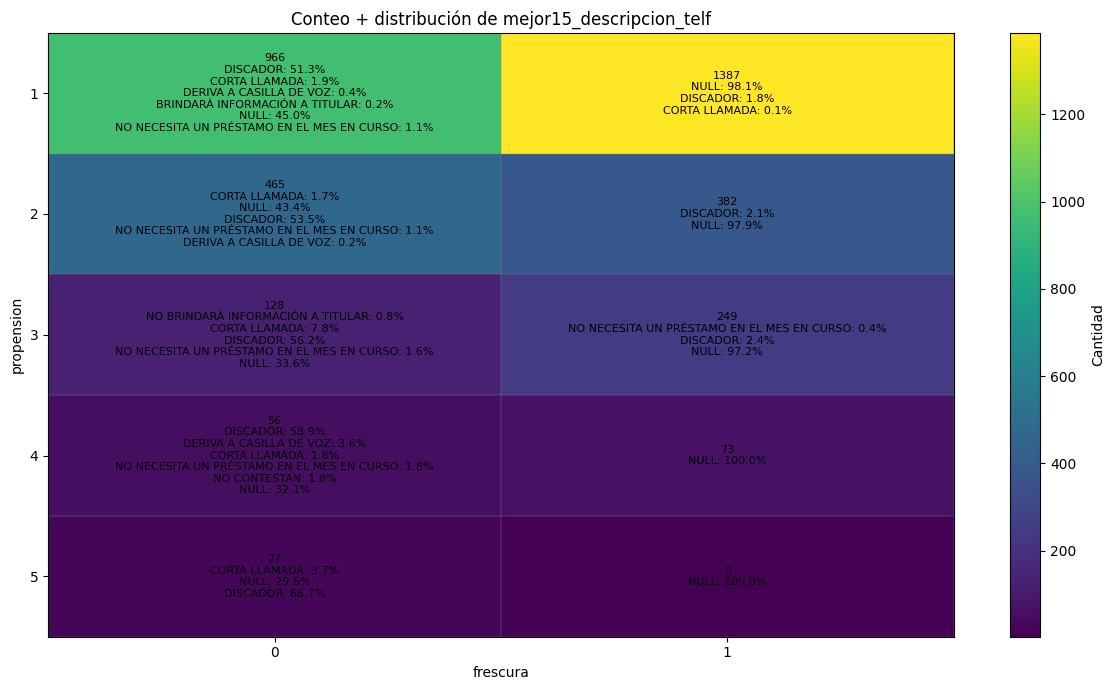

In [9]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# 1) AGRUPAR POR 3 VARIABLES
# =====================================================
df_plot = (
    df_filtrado
    .groupBy(
        "propension",
        "frescura",
        "mejor15_descripcion_telf"
    )
    .count()
)

pdf = df_plot.toPandas()

pdf["propension"] = pdf["propension"].fillna("NULL").astype(str)
pdf["frescura"] = pdf["frescura"].fillna("NULL").astype(str)
pdf["mejor15_descripcion_telf"] = pdf["mejor15_descripcion_telf"].fillna("NULL").astype(str)

# =====================================================
# 2) TOTAL POR PRODUCTO + PROPENSION
# =====================================================
pdf["total_celda"] = pdf.groupby(
    ["propension", "frescura"]
)["count"].transform("sum")

pdf["pct"] = pdf["count"] / pdf["total_celda"] * 100

# =====================================================
# 3) TABLA DE VOLUMEN TOTAL
# =====================================================
tabla = pdf.pivot_table(
    index="propension",
    columns="frescura",
    values="total_celda",
    aggfunc="max"
).fillna(0)

tabla = tabla.sort_index()
tabla = tabla.reindex(sorted(tabla.columns, key=lambda x: str(x)), axis=1)

# =====================================================
# 4) GRAFICAR
# =====================================================
fig, ax = plt.subplots(figsize=(12, 7))

im = ax.imshow(tabla.values, aspect="auto")

ax.set_title("Conteo + distribución de mejor15_descripcion_telf")
ax.set_xlabel("frescura")
ax.set_ylabel("propension")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)

ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# grilla
ax.set_xticks(np.arange(-.5, len(tabla.columns), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(tabla.index), 1), minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.3)
ax.tick_params(which="minor", bottom=False, left=False)

# =====================================================
# 5) TEXTO DENTRO DE CADA CELDA
# =====================================================
for i, producto in enumerate(tabla.index):
    for j, propension in enumerate(tabla.columns):

        total = int(tabla.loc[producto, propension])

        subset = pdf[
            (pdf["propension"] == producto) &
            (pdf["frescura"] == propension)
        ]

        texto_estados = "\n".join(
            subset.apply(
                lambda x: f"{x['mejor15_descripcion_telf']}: {x['pct']:.1f}%",
                axis=1
            )
        )

        texto = f"{total}\n{texto_estados}"

        ax.text(
            j, i,
            texto,
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(im, ax=ax, label="Cantidad")
plt.tight_layout()
plt.show()

In [24]:
df_filtrado.count()

2544

In [22]:
df_list_filtrada = df_parte_1.select(
    'cabecera_carga'
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'df_parte_1.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [13]:
df_list_filtrada = df_final.select(
    'cabecera_carga','region_comercial',"agencia_comercial"
).toPandas()
ruta_archivo = os.path.join(ruta_csv, 'alfin_.xlsx')
df_list_filtrada.to_excel(ruta_archivo, index=False)

In [12]:
from pyspark.sql.window import Window

window_agencia = Window.partitionBy('region_comercial',"agencia_comercial")

df_final = df_filtrado.withColumn(
    "cnt_agencia",
    F.count("*").over(window_agencia)
)
df_final=df_final.filter(
    F.col("cnt_agencia") > 450
)
print(df_final.count())


16295


In [ ]:
df_parte_1

In [70]:
print([row['cnt_agencia' ] for row in df_final.select('cnt_agencia').distinct().collect()])


[167, 184, 126, 274, 136, 369, 143, 107, 397, 178, 234, 138, 235, 185, 214, 179, 306, 254, 205, 352, 435, 382, 321, 102, 272, 298, 137, 194, 173, 315, 133, 312, 231, 251, 340]


In [28]:
spark.stop()

6100


In [41]:
print([row['cnt_agencia' ] for row in df_final.select('cnt_agencia').distinct().collect()])


[243, 330, 196, 427, 399, 202, 406, 343, 201, 157, 268, 369, 370, 161, 447, 178, 209, 170, 257, 307, 214, 448, 517, 218, 220, 331, 321, 199, 154, 244, 428, 245, 140, 125, 109, 169]


In [8]:
df_list.groupBy('grupo_monto') \
    .count() \
    .orderBy('grupo_monto') \
    .show(30, truncate=False)

+---------------+-----+
|grupo_monto    |count|
+---------------+-----+
|NULL           |36376|
|               |141  |
|Disminuye Monto|14137|
|Mantiene Monto |17964|
|Mejora Monto   |37753|
+---------------+-----+



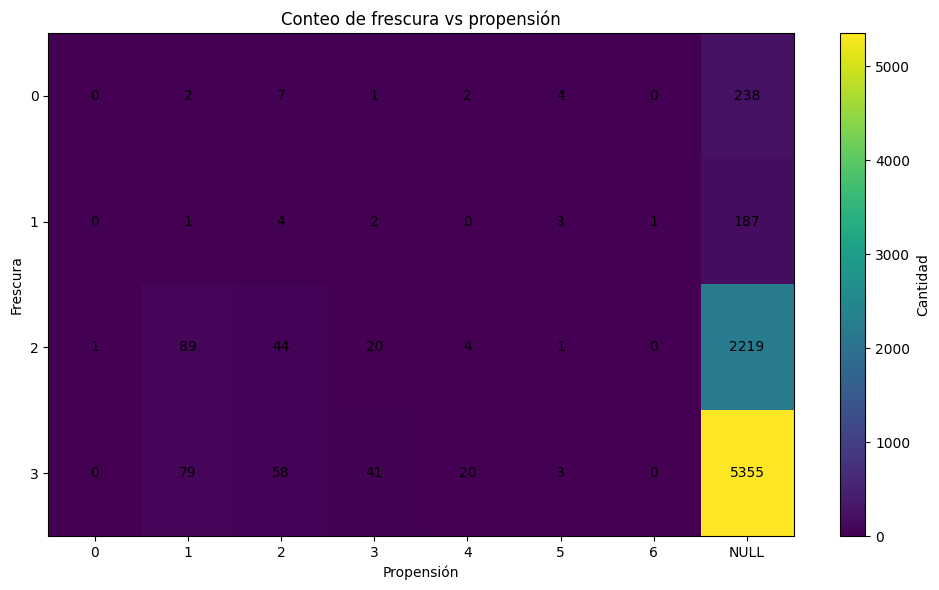

In [21]:
from pyspark.sql import functions as F
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df_plot = (
    df_final.groupBy("frescura", "propension")
    .count()
)

pdf = df_plot.toPandas()

pdf["propension"] = pdf["propension"].fillna("NULL").astype(str)
pdf["frescura"] = pdf["frescura"].fillna("NULL").astype(str)

tabla = pdf.pivot(index="frescura", columns="propension", values="count").fillna(0)
tabla = tabla.sort_index()
tabla = tabla.reindex(sorted(tabla.columns, key=lambda x: str(x)), axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(tabla.values, aspect="auto")

ax.set_title("Conteo de frescura vs propensión")
ax.set_xlabel("Propensión")
ax.set_ylabel("Frescura")

ax.set_xticks(np.arange(len(tabla.columns)))
ax.set_xticklabels(tabla.columns)
ax.set_yticks(np.arange(len(tabla.index)))
ax.set_yticklabels(tabla.index)

# mostrar etiquetas dentro de cada celda
for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        ax.text(j, i, int(tabla.iloc[i, j]), ha="center", va="center")

plt.colorbar(im, ax=ax, label="Cantidad")
plt.tight_layout()
plt.show()

In [14]:
df_final.groupBy('agencia_comercial') \
    .count() \
    .orderBy('agencia_comercial') \
    .show(100, truncate=False)

+----------------------+-----+
|agencia_comercial     |count|
+----------------------+-----+
|AREQUIPA CAYMA        |189  |
|AREQUIPA PAMPILLA     |294  |
|ATE VITARTE           |226  |
|CAJAMARCA             |108  |
|CASTILLA              |233  |
|CHICLAYO BALTA        |318  |
|CHIMBOTE              |158  |
|COMAS                 |228  |
|CUSCO LA CULTURA      |199  |
|EMANCIPACION          |234  |
|HUACHO                |110  |
|HUANUCO               |159  |
|ICA                   |146  |
|JESUS MARIA           |165  |
|LOS OLIVOS            |162  |
|MIRAFLORES            |329  |
|MOSHOQUEQUE           |135  |
|PC HUANCAYO           |284  |
|PC TACNA              |163  |
|SAN JUAN DE LURIGANCHO|255  |
|SAN JUAN DE MIRAFLORES|281  |
|SAN MARTIN            |227  |
|SAN MIGUEL            |319  |
|SANTA ANITA           |195  |
|SULLANA               |145  |
|TARAPOTO              |171  |
|TRUJILLO AMERICA      |132  |
|TRUJILLO CENTRO       |237  |
|VILLA EL SALVADOR 2   |175  |
|VILLA M

In [13]:
df_filtrado.groupBy('lote') \
    .count() \
    .orderBy('lote') \
    .show(30, truncate=False)

+---------------+-----+
|lote           |count|
+---------------+-----+
|BASE-2026-04-01|6208 |
|TARGET         |1497 |
+---------------+-----+



In [ ]:
df_filtrado.groupBy('region_comercial','agencia_comercial') \
    .count() \
    .orderBy('region_comercial') \
    .show(30, truncate=False)


In [12]:
df_filtrado.groupBy('lote') \
    .count() \
    .orderBy('lote') \
    .show(30, truncate=False)

+---------------+-----+
|lote           |count|
+---------------+-----+
|BASE-2026-04-01|8214 |
|TARGET         |11579|
+---------------+-----+



In [ ]:
df_list_cencosud.dropDuplicates(['region_comercial']) \
    .groupBy("quintil") \
    .count() \
    .orderBy("quintil") \
    .show()

+-------+-----+
|quintil|count|
+-------+-----+
|      1| 7706|
|      2| 7305|
|      3| 7784|
|      4| 7560|
|      5| 7927|
+-------+-----+

